# Day 7 — XGBoost Training & Evaluation

In [11]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

import joblib

# Load Dataset

In [12]:
dataset = pd.read_csv(
    "../data/processed/labeled_dataset.csv"
)

dataset.head()

,file,mean,std,rms,max,min,peak_to_peak,health_stage
0,2003.10.22.12.06.24,-0.094593,0.081124,0.124614,0.388,-0.720,1.108,Healthy
1,2003.10.22.12.09.13,-0.094903,0.079517,0.123811,0.388,-0.654,1.042,Healthy
2,2003.10.22.12.14.13,-0.096187,0.080219,0.125246,0.317,-0.623,0.940,Healthy
3,2003.10.22.12.19.13,-0.095613,0.080827,0.125197,0.457,-0.598,1.055,Healthy
4,2003.10.22.12.24.13,-0.095133,0.082036,0.125618,0.388,-0.623,1.011,Healthy


# Data Preparation

In [13]:
X = dataset.drop(
    columns=["file","health_stage"]
)

y = dataset["health_stage"]

print(X.shape)
print(y.shape)

(100, 6)
(100,)


In [14]:
encoder = LabelEncoder()

y = encoder.fit_transform(
    dataset["health_stage"]
)

print(encoder.classes_)

['Critical' 'Early_Degradation' 'Healthy' 'Imminent_Failure']


# Train XGBoost

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

# Model Evaluation

In [17]:
pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.40      0.67      0.50         3
           1       0.33      0.20      0.25         5
           2       0.82      0.90      0.86        10
           3       1.00      0.50      0.67         2

    accuracy                           0.65        20
   macro avg       0.64      0.57      0.57        20
weighted avg       0.65      0.65      0.63        20



# Save Model

In [18]:
joblib.dump(
    model,
    "../models/xgb_baseline.pkl"
)

['../models/xgb_baseline.pkl']

# Feature Importance

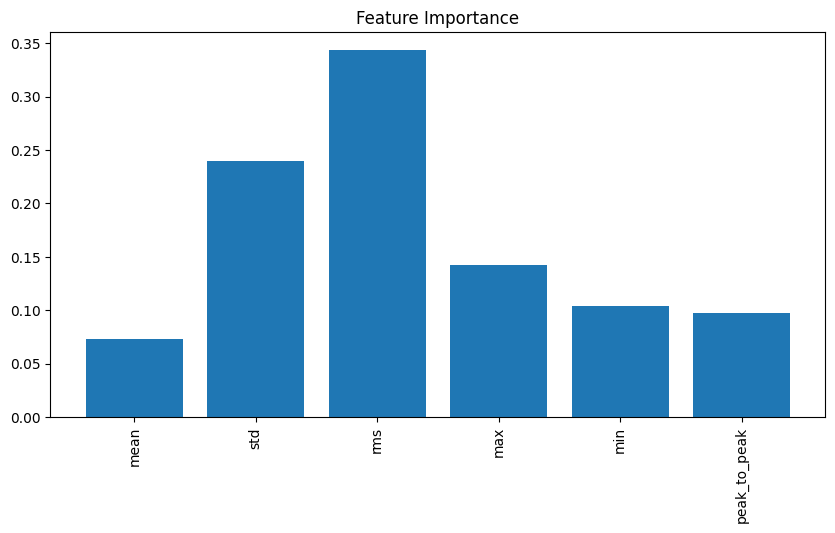

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    X.columns,
    model.feature_importances_
)

plt.xticks(rotation=90)

plt.title(
    "Feature Importance"
)

plt.show()